In [1]:
!python -m pip install medmnist
import sys
!{sys.executable} -m pip install --upgrade pip
!{sys.executable} -m pip install tensorflow

In [2]:
import os
import numpy as np

dataset_dir = r"D:\Projet ML\DATA\ChestMNIST"

npz_files = [f for f in os.listdir(dataset_dir) if f.endswith(".npz")]
npz_files.sort()

print("Fichiers trouvés :")
for f in npz_files:
    full_path = os.path.join(dataset_dir, f)
    size_gb = os.path.getsize(full_path) / (1024**3)
    print(f"- {f} | {size_gb:.2f} Go")

print("\n--- Inspection d'un fichier ---")
sample_file = os.path.join(dataset_dir, npz_files[0])
print("Fichier inspecté :", sample_file)

data = np.load(sample_file)

print("\nClés contenues dans le fichier :")
for key in data.files:
    arr = data[key]
    print(f"{key}: shape={arr.shape}, dtype={arr.dtype}")

Fichiers trouvés :
- chestmnist.npz | 0.08 Go
- chestmnist_128.npz | 1.33 Go
- chestmnist_224.npz | 3.62 Go
- chestmnist_64.npz | 0.37 Go

--- Inspection d'un fichier ---
Fichier inspecté : D:\Projet ML\DATA\ChestMNIST\chestmnist.npz

Clés contenues dans le fichier :
train_images: shape=(78468, 28, 28), dtype=uint8
val_images: shape=(11219, 28, 28), dtype=uint8
test_images: shape=(22433, 28, 28), dtype=uint8
train_labels: shape=(78468, 14), dtype=uint8
val_labels: shape=(11219, 14), dtype=uint8
test_labels: shape=(22433, 14), dtype=uint8


In [3]:
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt

from medmnist import INFO
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

# Seed
seed = 42
np.random.seed(seed)
tf.random.set_seed(seed)

# Chargement du dataset
dataset_path = r"D:\Projet ML\DATA\ChestMNIST\chestmnist_128.npz"
data = np.load(dataset_path)

X_train = data["train_images"]
X_val = data["val_images"]
X_test = data["test_images"]

y_train = data["train_labels"]
y_val = data["val_labels"]
y_test = data["test_labels"]

print("=== Shapes initiales ===")
print("X_train :", X_train.shape, X_train.dtype)
print("X_val   :", X_val.shape, X_val.dtype)
print("X_test  :", X_test.shape, X_test.dtype)
print("y_train :", y_train.shape, y_train.dtype)
print("y_val   :", y_val.shape, y_val.dtype)
print("y_test  :", y_test.shape, y_test.dtype)

# Ajout du canal
X_train = np.expand_dims(X_train, axis=-1)
X_val = np.expand_dims(X_val, axis=-1)
X_test = np.expand_dims(X_test, axis=-1)

# Normalisation
X_train = X_train.astype(np.float32) / 255.0
X_val = X_val.astype(np.float32) / 255.0
X_test = X_test.astype(np.float32) / 255.0

# Labels en float32
y_train = y_train.astype(np.float32)
y_val = y_val.astype(np.float32)
y_test = y_test.astype(np.float32)

print("\n=== Shapes après préparation ===")
print("X_train :", X_train.shape, X_train.dtype)
print("X_val   :", X_val.shape, X_val.dtype)
print("X_test  :", X_test.shape, X_test.dtype)

# Labels officiels
info = INFO["chestmnist"]

if isinstance(info["label"], dict):
    label_names = [info["label"][str(i)] if str(i) in info["label"] else info["label"][i] for i in range(len(info["label"]))]
else:
    label_names = list(info["label"])

print("\n=== Labels ===")
for i, name in enumerate(label_names):
    print(i, ":", name)

# Comptage du nombre de labels positifs par image
train_positive_counts = y_train.sum(axis=1)
val_positive_counts = y_val.sum(axis=1)
test_positive_counts = y_test.sum(axis=1)

print("\n=== Répartition images normales / anormales ===")
print("Train normales  :", np.sum(train_positive_counts == 0))
print("Train anormales :", np.sum(train_positive_counts > 0))
print("Val normales    :", np.sum(val_positive_counts == 0))
print("Val anormales   :", np.sum(val_positive_counts > 0))
print("Test normales   :", np.sum(test_positive_counts == 0))
print("Test anormales  :", np.sum(test_positive_counts > 0))

# Option AE : entraînement sur images sans label positif uniquement
X_train_normal = X_train[train_positive_counts == 0]
X_val_normal = X_val[val_positive_counts == 0]

print("\n=== Données utilisées pour entraîner l'AE ===")
print("X_train_normal :", X_train_normal.shape)
print("X_val_normal   :", X_val_normal.shape)

# Datasets TensorFlow AE
batch_size = 32

train_ds_ae = tf.data.Dataset.from_tensor_slices((X_train_normal, X_train_normal))
train_ds_ae = train_ds_ae.shuffle(buffer_size=len(X_train_normal), seed=seed, reshuffle_each_iteration=True)
train_ds_ae = train_ds_ae.batch(batch_size).prefetch(tf.data.AUTOTUNE)

val_ds_ae = tf.data.Dataset.from_tensor_slices((X_val_normal, X_val_normal))
val_ds_ae = val_ds_ae.batch(batch_size).prefetch(tf.data.AUTOTUNE)

test_ds_ae = tf.data.Dataset.from_tensor_slices((X_test, X_test))
test_ds_ae = test_ds_ae.batch(batch_size).prefetch(tf.data.AUTOTUNE)

print("\n=== Vérification datasets AE ===")
print("Train AE :", train_ds_ae)
print("Val AE   :", val_ds_ae)
print("Test AE  :", test_ds_ae)

for batch_x, batch_y in train_ds_ae.take(1):
    print("\n=== Batch AE ===")
    print("Input shape  :", batch_x.shape)
    print("Target shape :", batch_y.shape)
    print("Min pixel    :", tf.reduce_min(batch_x).numpy())
    print("Max pixel    :", tf.reduce_max(batch_x).numpy())

# Autoencodeur convolutionnel
encoder_inputs = layers.Input(shape=(128, 128, 1))

x = layers.Conv2D(32, 3, activation="relu", padding="same")(encoder_inputs)
x = layers.MaxPooling2D(2, padding="same")(x)

x = layers.Conv2D(64, 3, activation="relu", padding="same")(x)
x = layers.MaxPooling2D(2, padding="same")(x)

x = layers.Conv2D(128, 3, activation="relu", padding="same")(x)
encoded = layers.MaxPooling2D(2, padding="same", name="latent_space")(x)

x = layers.Conv2D(128, 3, activation="relu", padding="same")(encoded)
x = layers.UpSampling2D(2)(x)

x = layers.Conv2D(64, 3, activation="relu", padding="same")(x)
x = layers.UpSampling2D(2)(x)

x = layers.Conv2D(32, 3, activation="relu", padding="same")(x)
x = layers.UpSampling2D(2)(x)

decoded = layers.Conv2D(1, 3, activation="sigmoid", padding="same")(x)

ae_model = models.Model(encoder_inputs, decoded, name="conv_autoencoder_chestmnist")

ae_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss="mse"
)

print("\n=== Summary de l'Autoencodeur ===")
ae_model.summary()

callbacks_ae = [
    EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=2,
        min_lr=1e-6,
        verbose=1
    ),
    ModelCheckpoint(
        "best_conv_autoencoder.keras",
        monitor="val_loss",
        save_best_only=True,
        verbose=1
    )
]

=== Shapes initiales ===
X_train : (78468, 128, 128) uint8
X_val   : (11219, 128, 128) uint8
X_test  : (22433, 128, 128) uint8
y_train : (78468, 14) uint8
y_val   : (11219, 14) uint8
y_test  : (22433, 14) uint8

=== Shapes après préparation ===
X_train : (78468, 128, 128, 1) float32
X_val   : (11219, 128, 128, 1) float32
X_test  : (22433, 128, 128, 1) float32

=== Labels ===
0 : atelectasis
1 : cardiomegaly
2 : effusion
3 : infiltration
4 : mass
5 : nodule
6 : pneumonia
7 : pneumothorax
8 : consolidation
9 : edema
10 : emphysema
11 : fibrosis
12 : pleural
13 : hernia

=== Répartition images normales / anormales ===
Train normales  : 42405
Train anormales : 36063
Val normales    : 6079
Val anormales   : 5140
Test normales   : 11928
Test anormales  : 10505

=== Données utilisées pour entraîner l'AE ===
X_train_normal : (42405, 128, 128, 1)
X_val_normal   : (6079, 128, 128, 1)

=== Vérification datasets AE ===
Train AE : <_PrefetchDataset element_spec=(TensorSpec(shape=(None, 128, 128, 1)

Model: "conv_autoencoder_chestmnist"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 128, 128, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ latent_space (MaxPooling2D)     │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d (UpSampling2D)    │ (None, 32, 32, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 32, 32, 64)     │        73,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_1 (UpSampling2D)  │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 64, 64, 32)     │        18,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_2 (UpSampling2D)  │ (None, 128, 128, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 128, 128, 1)    │           289 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 332,801 (1.27 MB)

 Trainable params: 332,801 (1.27 MB)

 Non-trainable params: 0 (0.00 B)

## Initialisation de la composante de détection d’anomalies par autoencodeur

La section de détection d’anomalies est initialisée à partir du dataset **ChestMNIST_128** déjà utilisé dans la partie supervisée. Les images ont été préparées de la même manière :

- ajout d’un canal explicite ;
- normalisation dans l’intervalle `[0,1]` ;
- conservation des labels pour distinguer les cas normaux et anormaux.

### 1. Principe retenu

L’approche choisie ici consiste à entraîner un **autoencodeur convolutionnel (AE)** sur les images considérées comme **normales**, c’est-à-dire les radiographies ne possédant aucun label positif. L’idée est que le modèle apprenne à bien reconstruire les cas normaux, tandis que les images atypiques ou pathologiques devraient produire une erreur de reconstruction plus élevée.

Cette stratégie est cohérente avec l’objectif du sujet : obtenir un **score d’anomalie fondé sur la reconstruction** afin d’identifier des cas atypiques, ambigus ou hors distribution.

### 2. Architecture de l’AE

L’autoencodeur construit est un **autoencodeur convolutionnel symétrique** :

- partie encodeur :
  - convolutions successives
  - réductions spatiales par max pooling
- espace latent :
  - représentation compressée en **16 × 16 × 128**
- partie décodeur :
  - convolutions
  - remontée de résolution par `UpSampling2D`
  - sortie finale en **sigmoïde**

Le modèle totalise environ **332 801 paramètres**, ce qui reste relativement léger par rapport aux architectures supervisées testées précédemment.

### 3. Lecture pratique

L’AE est plus compact que les modèles de classification, ce qui est intéressant dans un cadre expérimental où l’on souhaite tester rapidement un score d’anomalie basé sur l’erreur de reconstruction. La prochaine étape consiste à l’entraîner sur les images normales, puis à comparer les erreurs de reconstruction obtenues sur :

- les images normales ;
- les images pathologiques ;
- quelques cas individuels représentatifs.

In [4]:
history_ae = ae_model.fit(
    train_ds_ae,
    validation_data=val_ds_ae,
    epochs=15,
    callbacks=callbacks_ae,
    verbose=1
)

Epoch 1/15
1325/1326 ━━━━━━━━━━━━━━━━━━━━ 0s 106ms/step - loss: 0.0061
Epoch 1: val_loss improved from None to 0.00065, saving model to best_conv_autoencoder.keras

Epoch 1: finished saving model to best_conv_autoencoder.keras
1326/1326 ━━━━━━━━━━━━━━━━━━━━ 151s 112ms/step - loss: 0.0021 - val_loss: 6.5048e-04 - learning_rate: 0.0010
Epoch 2/15
1325/1326 ━━━━━━━━━━━━━━━━━━━━ 0s 110ms/step - loss: 6.3028e-04
Epoch 2: val_loss improved from 0.00065 to 0.00050, saving model to best_conv_autoencoder.keras

Epoch 2: finished saving model to best_conv_autoencoder.keras
1326/1326 ━━━━━━━━━━━━━━━━━━━━ 152s 115ms/step - loss: 5.8258e-04 - val_loss: 4.9849e-04 - learning_rate: 0.0010
Epoch 3/15
1325/1326 ━━━━━━━━━━━━━━━━━━━━ 0s 109ms/step - loss: 4.9707e-04
Epoch 3: val_loss improved from 0.00050 to 0.00041, saving model to best_conv_autoencoder.keras

Epoch 3: finished saving model to best_conv_autoencoder.keras
1326/1326 ━━━━━━━━━━━━━━━━━━━━ 152s 115ms/step - loss: 4.7058e-04 - val_loss: 4.132

## Interprétation de l’entraînement de l’autoencodeur

L’autoencodeur convolutionnel a été entraîné sur les images normales, c’est-à-dire les radiographies sans label positif. L’objectif était d’apprendre une représentation compacte des cas considérés comme non pathologiques afin de reconstruire correctement ces images.

### 1. Évolution de la loss

La loss d’entraînement diminue fortement au cours des epochs, passant d’une valeur initiale plus élevée à environ **2,28e-04** en validation à la fin de l’entraînement. La loss de validation suit également une trajectoire descendante régulière, ce qui indique que le modèle apprend effectivement à reconstruire les images normales et que l’apprentissage reste stable.

### 2. Qualité de l’apprentissage

La baisse progressive de la `val_loss` jusqu’à la dernière epoch montre que l’autoencodeur continue à améliorer ses reconstructions. L’utilisation de `ReduceLROnPlateau` a permis de diminuer progressivement le learning rate, ce qui a favorisé un affinement des paramètres dans les dernières epochs.

### 3. Interprétation méthodologique

Un autoencodeur bien entraîné sur les cas normaux doit produire :

- une **faible erreur de reconstruction** pour les images normales ;
- une **erreur plus élevée** pour les images atypiques ou pathologiques.

La prochaine étape est donc essentielle : il faut mesurer l’erreur de reconstruction image par image sur le jeu de test, puis vérifier si cette erreur permet bien de distinguer les cas normaux des cas anormaux.

        loss  val_loss  learning_rate
0   0.002130  0.000650       0.001000
1   0.000583  0.000498       0.001000
2   0.000471  0.000413       0.001000
3   0.000414  0.000352       0.001000
4   0.000368  0.000465       0.001000
5   0.000344  0.000357       0.001000
6   0.000284  0.000277       0.000500
7   0.000277  0.000265       0.000500
8   0.000256  0.000251       0.000250
9   0.000251  0.000246       0.000250
10  0.000245  0.000239       0.000250
11  0.000236  0.000234       0.000125
12  0.000233  0.000232       0.000125
13  0.000229  0.000229       0.000063
14  0.000228  0.000228       0.000063


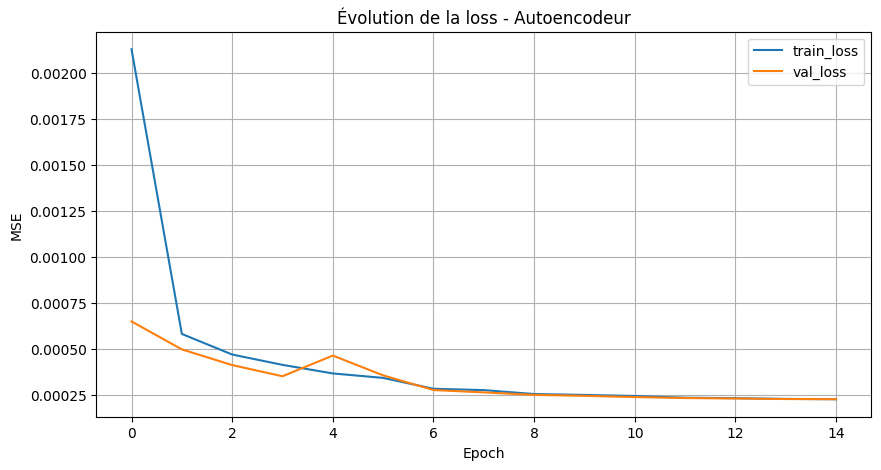

190/190 ━━━━━━━━━━━━━━━━━━━━ 8s 42ms/step
702/702 ━━━━━━━━━━━━━━━━━━━━ 26s 38ms/step
Shapes reconstructions
X_val_normal      : (6079, 128, 128, 1)
X_val_normal_pred : (6079, 128, 128, 1)
X_test            : (22433, 128, 128, 1)
X_test_pred       : (22433, 128, 128, 1)

=== Statistiques erreur reconstruction ===
Validation normale
min   : 1.3596426e-05
mean  : 0.00022777948
std   : 9.552169e-05
max   : 0.001095952

Test global
min   : 9.907393e-06
mean  : 0.00022877575
std   : 0.000101019505
max   : 0.0017751142

=== Répartition test ===
Normales  : 11928
Anormales : 10505

=== Erreur reconstruction par groupe ===
Normales
mean : 0.00022544728 | std : 9.6361466e-05 | median : 0.00021630197
Anormales
mean : 0.00023255507 | std : 0.00010593408 | median : 0.00022058024


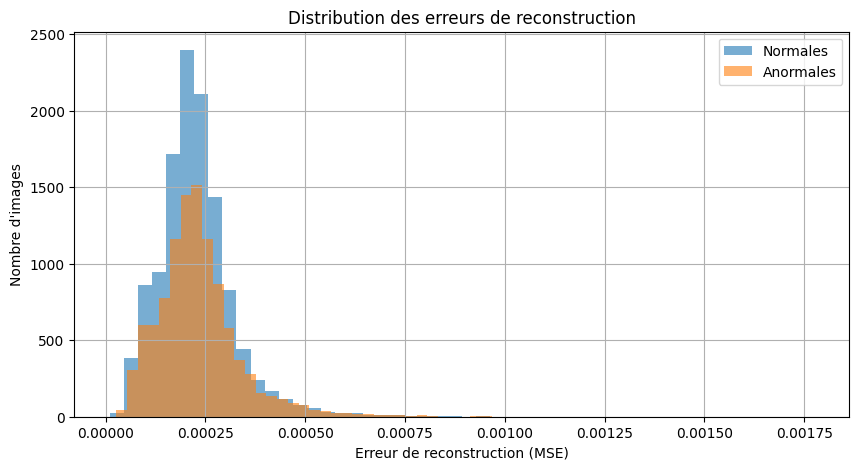

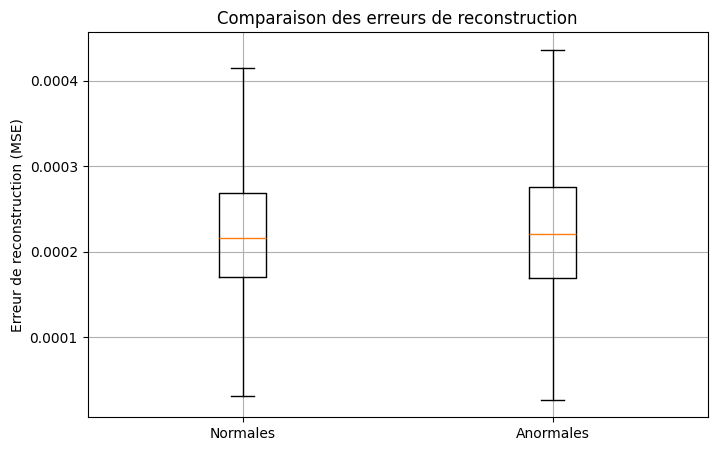


=== Performance du score d'anomalie ===
ROC-AUC anomalie : 0.5141
AP anomalie      : 0.4901

=== Seuils d'anomalie basés sur validation normale ===
Seuil 95e percentile : 0.00039448496
Seuil 99e percentile : 0.0005578877

=== Taux de détection ===
Avec seuil 95
Images prédites anormales : 1250 / 22433
Avec seuil 99
Images prédites anormales : 262 / 22433


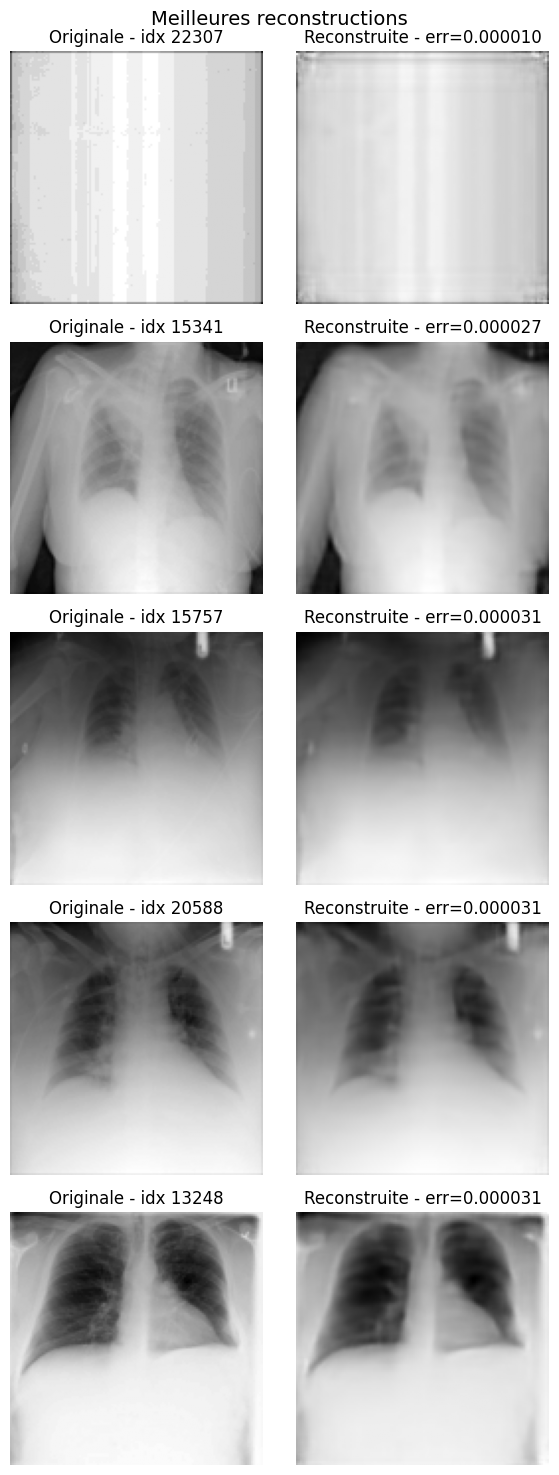

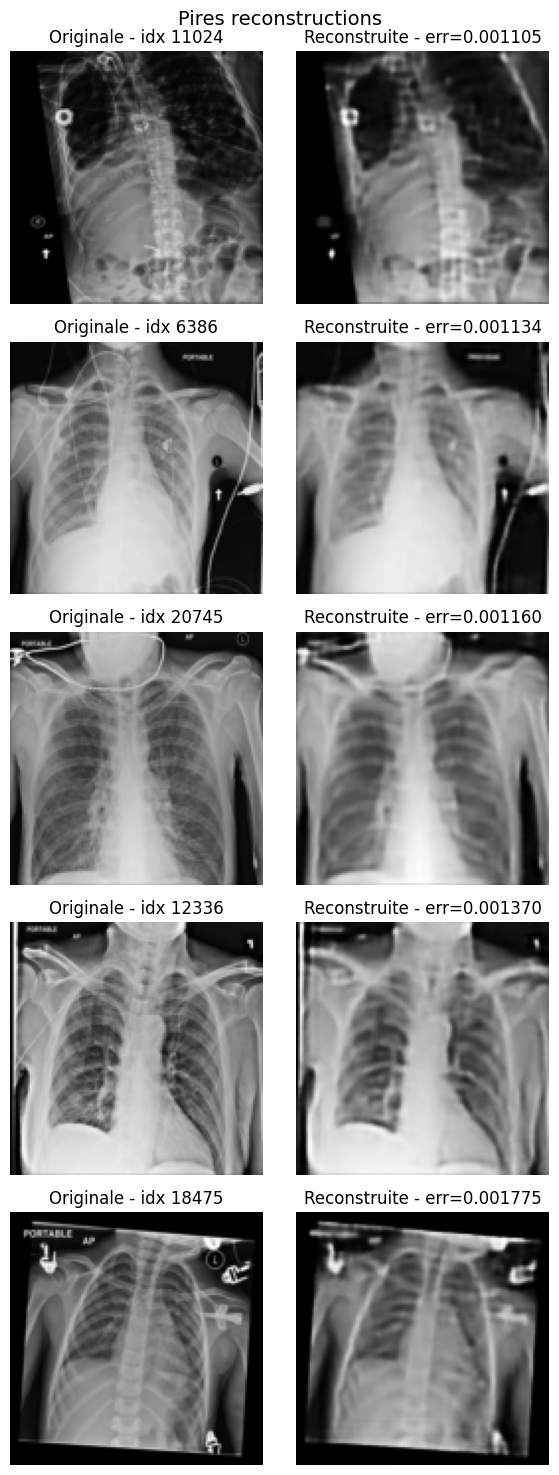


=== Aperçu tableau résultats AE ===
   index  reconstruction_error  is_anomaly  num_positive_labels
0      0              0.000208           0                    0
1      1              0.000235           0                    0
2      2              0.000230           1                    1
3      3              0.000205           0                    0
4      4              0.000259           0                    0

=== Top 10 plus fortes erreurs de reconstruction ===
 index  reconstruction_error  is_anomaly  num_positive_labels
 18475              0.001775           0                    0
 12336              0.001370           1                    1
 20745              0.001160           1                    1
  6386              0.001134           0                    0
 11024              0.001105           1                    1
  1885              0.001076           0                    0
 13559              0.001064           0                    0
  1116              0.001043 

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import roc_auc_score, average_precision_score

# Historique AE
history_ae_df = pd.DataFrame(history_ae.history)
print(history_ae_df)

# Courbe loss
plt.figure(figsize=(10, 5))
plt.plot(history_ae_df["loss"], label="train_loss")
plt.plot(history_ae_df["val_loss"], label="val_loss")
plt.title("Évolution de la loss - Autoencodeur")
plt.xlabel("Epoch")
plt.ylabel("MSE")
plt.legend()
plt.grid(True)
plt.show()

# Reconstructions
X_val_normal_pred = ae_model.predict(X_val_normal, verbose=1)
X_test_pred = ae_model.predict(X_test, verbose=1)

print("Shapes reconstructions")
print("X_val_normal      :", X_val_normal.shape)
print("X_val_normal_pred :", X_val_normal_pred.shape)
print("X_test            :", X_test.shape)
print("X_test_pred       :", X_test_pred.shape)

# Erreur de reconstruction par image
val_recon_error = np.mean((X_val_normal - X_val_normal_pred) ** 2, axis=(1, 2, 3))
test_recon_error = np.mean((X_test - X_test_pred) ** 2, axis=(1, 2, 3))

print("\n=== Statistiques erreur reconstruction ===")
print("Validation normale")
print("min   :", val_recon_error.min())
print("mean  :", val_recon_error.mean())
print("std   :", val_recon_error.std())
print("max   :", val_recon_error.max())

print("\nTest global")
print("min   :", test_recon_error.min())
print("mean  :", test_recon_error.mean())
print("std   :", test_recon_error.std())
print("max   :", test_recon_error.max())

# Définition normal / anormal sur test
test_is_anomaly = (y_test.sum(axis=1) > 0).astype(int)

print("\n=== Répartition test ===")
print("Normales  :", np.sum(test_is_anomaly == 0))
print("Anormales :", np.sum(test_is_anomaly == 1))

# Comparaison normale vs anormale
normal_errors = test_recon_error[test_is_anomaly == 0]
abnormal_errors = test_recon_error[test_is_anomaly == 1]

print("\n=== Erreur reconstruction par groupe ===")
print("Normales")
print("mean :", normal_errors.mean(), "| std :", normal_errors.std(), "| median :", np.median(normal_errors))

print("Anormales")
print("mean :", abnormal_errors.mean(), "| std :", abnormal_errors.std(), "| median :", np.median(abnormal_errors))

# Histogrammes
plt.figure(figsize=(10, 5))
plt.hist(normal_errors, bins=50, alpha=0.6, label="Normales")
plt.hist(abnormal_errors, bins=50, alpha=0.6, label="Anormales")
plt.title("Distribution des erreurs de reconstruction")
plt.xlabel("Erreur de reconstruction (MSE)")
plt.ylabel("Nombre d'images")
plt.legend()
plt.grid(True)
plt.show()

# Boxplot
plt.figure(figsize=(8, 5))
plt.boxplot([normal_errors, abnormal_errors], tick_labels=["Normales", "Anormales"], showfliers=False)
plt.title("Comparaison des erreurs de reconstruction")
plt.ylabel("Erreur de reconstruction (MSE)")
plt.grid(True)
plt.show()

# Score d’anomalie : erreur de reconstruction
roc_auc_ae = roc_auc_score(test_is_anomaly, test_recon_error)
ap_ae = average_precision_score(test_is_anomaly, test_recon_error)

print("\n=== Performance du score d'anomalie ===")
print(f"ROC-AUC anomalie : {roc_auc_ae:.4f}")
print(f"AP anomalie      : {ap_ae:.4f}")

# Seuil basé sur la validation normale
threshold_95 = np.percentile(val_recon_error, 95)
threshold_99 = np.percentile(val_recon_error, 99)

print("\n=== Seuils d'anomalie basés sur validation normale ===")
print("Seuil 95e percentile :", threshold_95)
print("Seuil 99e percentile :", threshold_99)

test_pred_anomaly_95 = (test_recon_error >= threshold_95).astype(int)
test_pred_anomaly_99 = (test_recon_error >= threshold_99).astype(int)

# Taux détectés
print("\n=== Taux de détection ===")
print("Avec seuil 95")
print("Images prédites anormales :", test_pred_anomaly_95.sum(), "/", len(test_pred_anomaly_95))

print("Avec seuil 99")
print("Images prédites anormales :", test_pred_anomaly_99.sum(), "/", len(test_pred_anomaly_99))

# Visualisation de reconstructions
def show_reconstructions(originals, reconstructions, indices, title):
    n = len(indices)
    fig, axes = plt.subplots(n, 2, figsize=(6, 3 * n))
    fig.suptitle(title, fontsize=14)

    if n == 1:
        axes = np.expand_dims(axes, axis=0)

    for row, idx in enumerate(indices):
        axes[row, 0].imshow(originals[idx].squeeze(), cmap="gray")
        axes[row, 0].set_title(f"Originale - idx {idx}")
        axes[row, 0].axis("off")

        axes[row, 1].imshow(reconstructions[idx].squeeze(), cmap="gray")
        axes[row, 1].set_title(f"Reconstruite - err={test_recon_error[idx]:.6f}")
        axes[row, 1].axis("off")

    plt.tight_layout()
    plt.show()

# Meilleures et pires reconstructions sur test
best_idx = np.argsort(test_recon_error)[:5]
worst_idx = np.argsort(test_recon_error)[-5:]

show_reconstructions(X_test, X_test_pred, best_idx, "Meilleures reconstructions")
show_reconstructions(X_test, X_test_pred, worst_idx, "Pires reconstructions")

# Tableau résumé
df_ae_results = pd.DataFrame({
    "index": np.arange(len(test_recon_error)),
    "reconstruction_error": test_recon_error,
    "is_anomaly": test_is_anomaly,
    "num_positive_labels": y_test.sum(axis=1).astype(int)
})

print("\n=== Aperçu tableau résultats AE ===")
print(df_ae_results.head())

print("\n=== Top 10 plus fortes erreurs de reconstruction ===")
print(df_ae_results.sort_values("reconstruction_error", ascending=False).head(10).to_string(index=False))

## Interprétation des résultats de l’autoencodeur

L’autoencodeur convolutionnel a bien convergé sur les images normales. La loss d’entraînement et de validation diminuent régulièrement jusqu’à atteindre environ **2,28e-04** en validation. Cela montre que le modèle apprend correctement à reconstruire les radiographies considérées comme normales.

### 1. Qualité de reconstruction

Les meilleures reconstructions confirment que l’AE est capable de reproduire la structure globale des radiographies thoraciques : forme des poumons, contraste général, silhouette thoracique. Les reconstructions restent toutefois légèrement plus lissées que les images originales, ce qui est classique pour un autoencodeur entraîné avec une loss de type MSE.

Les pires reconstructions présentent souvent des cas plus difficiles visuellement :
- artefacts d’acquisition,
- contraste atypique,
- cadrage inhabituel,
- éléments parasites,
- ou structures plus complexes à reconstruire.

### 2. Séparation normales / anormales

L’erreur moyenne de reconstruction est légèrement plus élevée pour les images anormales que pour les images normales :

- normales : moyenne ≈ **0,000225**
- anormales : moyenne ≈ **0,000233**

Cette différence existe, mais elle reste très faible. Les histogrammes et les boxplots montrent un **fort recouvrement** entre les deux distributions. Cela signifie que l’erreur de reconstruction seule ne permet pas de séparer efficacement les cas normaux et les cas pathologiques dans cette configuration.

### 3. Performance du score d’anomalie

Le score d’anomalie défini par l’erreur de reconstruction obtient :

- **ROC-AUC anomalie = 0,5141**
- **Average Precision = 0,4901**

Ces résultats sont faibles et proches d’un comportement quasi aléatoire. En pratique, cela signifie que l’autoencodeur, dans cette configuration, n’est pas suffisamment discriminant pour servir seul de détecteur fiable d’anomalies médicales.

### 4. Interprétation méthodologique

Ce résultat est intéressant d’un point de vue expérimental. Il montre que :

- un autoencodeur peut très bien apprendre à reconstruire les images normales ;
- mais cette bonne reconstruction ne garantit pas automatiquement une bonne détection des pathologies ;
- l’erreur de reconstruction semble ici capturer autant des variations d’apparence globale, de qualité d’image ou de distribution visuelle que des anomalies médicales réelles.

Autrement dit, l’AE semble sensible aux **cas atypiques au sens visuel**, mais pas nécessairement aux **cas pathologiques au sens clinique**.

### 5. Seuils d’anomalie

Deux seuils ont été calculés à partir des images normales de validation :

- **95e percentile** : 0,000394
- **99e percentile** : 0,000558

Ces seuils permettent de définir une règle simple de détection. Cependant, même avec cette stratégie, le nombre d’images détectées comme anormales reste limité et la séparation globale demeure peu convaincante.

### 6. Conclusion sur l’AE

L’autoencodeur convolutionnel satisfait bien la contrainte technique du projet et permet de produire un **score d’anomalie basé sur la reconstruction**. En revanche, ses performances montrent que cette approche reste limitée pour distinguer les radiographies normales des radiographies pathologiques dans ce cadre expérimental.

Cette composante reste néanmoins utile :
- comme preuve de concept ;
- comme outil d’analyse qualitative des cas atypiques ;
- et comme base de discussion dans la partie critique du rapport.

=== Erreur selon le nombre de labels positifs ===
 num_positive_labels  count     mean   median      std
                   0  11928 0.000225 0.000216 0.000096
                   1   6259 0.000230 0.000219 0.000104
                   2   2914 0.000236 0.000223 0.000106
                   3    989 0.000240 0.000224 0.000115
                   4    275 0.000239 0.000228 0.000105
                   5     54 0.000254 0.000231 0.000119
                   6     12 0.000209 0.000205 0.000076
                   7      2 0.000236 0.000236 0.000012


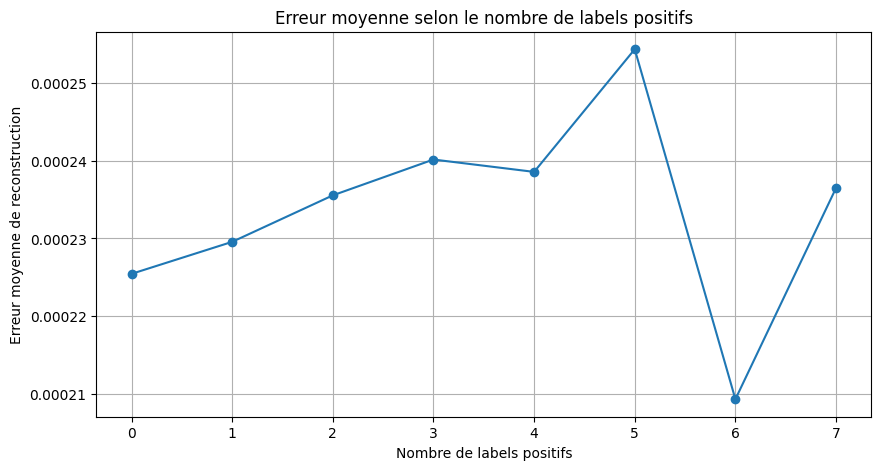


=== Erreur moyenne par pathologie ===
        label  count  mean_reconstruction_error  median_reconstruction_error  std_reconstruction_error
 pneumothorax   1089                   0.000256                     0.000244                  0.000115
    pneumonia    242                   0.000255                     0.000230                  0.000117
    emphysema    509                   0.000245                     0.000231                  0.000116
     fibrosis    362                   0.000242                     0.000231                  0.000075
       nodule   1335                   0.000241                     0.000224                  0.000103
consolidation    957                   0.000237                     0.000213                  0.000125
 infiltration   3938                   0.000236                     0.000222                  0.000111
     effusion   2754                   0.000234                     0.000224                  0.000100
      pleural    734              

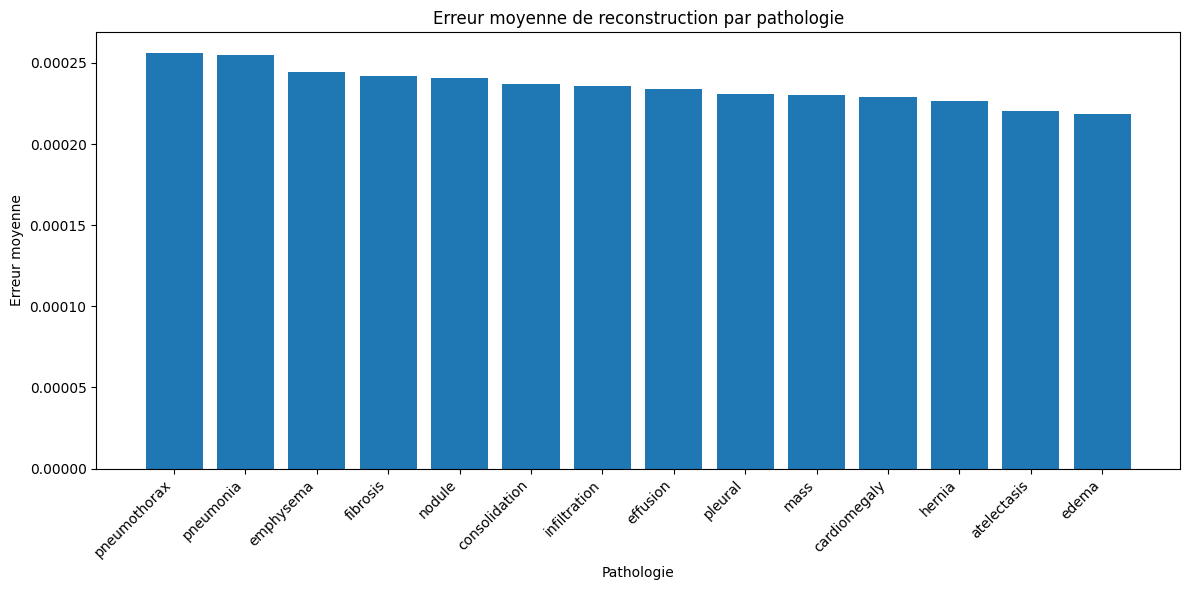


=== Top 12 des cas les plus atypiques ===
 index  reconstruction_error  is_anomaly  num_positive_labels                    labels
 18475              0.001775           0                    0       aucun label positif
 12336              0.001370           1                    1                   pleural
 20745              0.001160           1                    1              infiltration
  6386              0.001134           0                    0       aucun label positif
 11024              0.001105           1                    1                    nodule
  1885              0.001076           0                    0       aucun label positif
 13559              0.001064           0                    0       aucun label positif
  1116              0.001043           1                    1              infiltration
 10737              0.001019           1                    2 atelectasis, infiltration
  9136              0.001003           0                    0       aucun lab

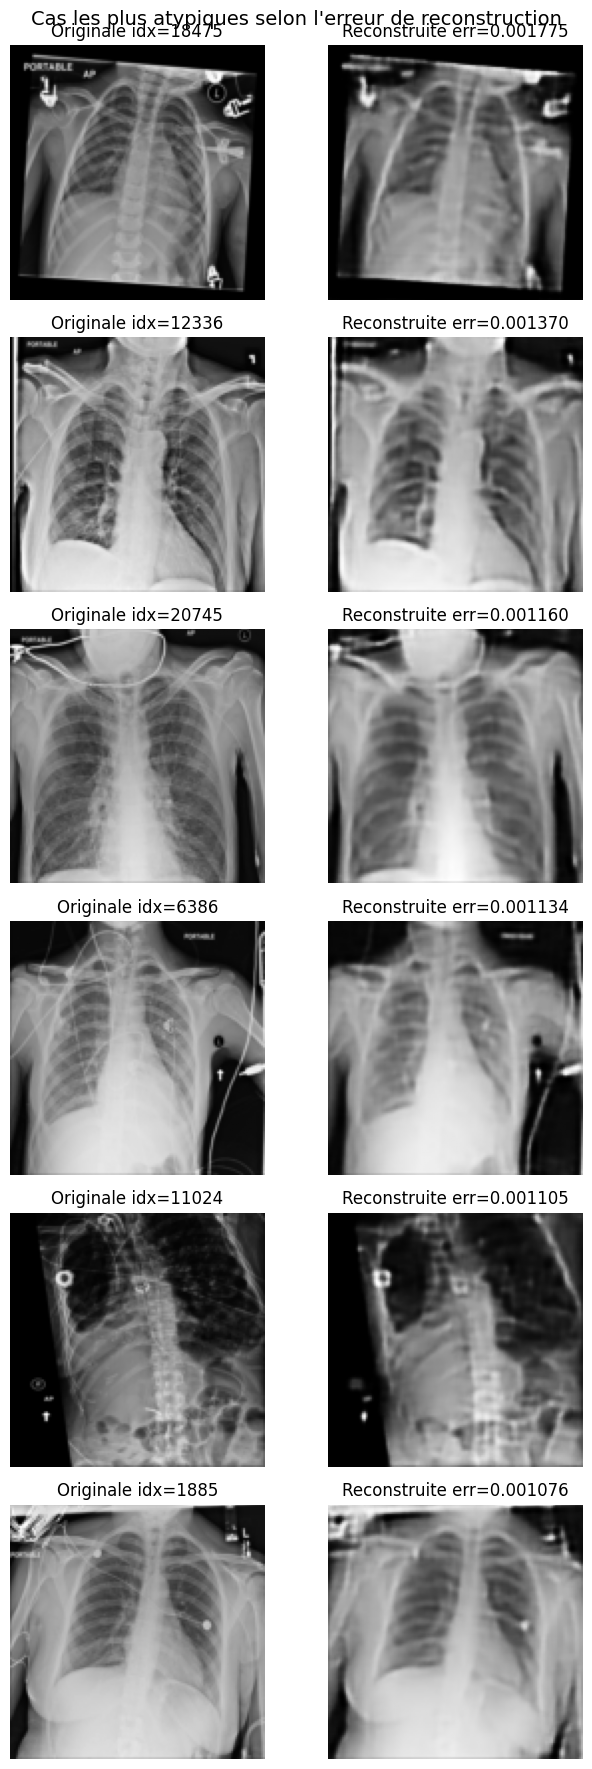

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Tableau complet test
df_ae_analysis = pd.DataFrame({
    "index": np.arange(len(X_test)),
    "reconstruction_error": test_recon_error,
    "is_anomaly": (y_test.sum(axis=1) > 0).astype(int),
    "num_positive_labels": y_test.sum(axis=1).astype(int)
})

# Erreur selon le nombre de labels positifs
error_by_label_count = (
    df_ae_analysis
    .groupby("num_positive_labels")["reconstruction_error"]
    .agg(["count", "mean", "median", "std"])
    .reset_index()
)

print("=== Erreur selon le nombre de labels positifs ===")
print(error_by_label_count.to_string(index=False))

plt.figure(figsize=(10, 5))
plt.plot(error_by_label_count["num_positive_labels"], error_by_label_count["mean"], marker="o")
plt.title("Erreur moyenne selon le nombre de labels positifs")
plt.xlabel("Nombre de labels positifs")
plt.ylabel("Erreur moyenne de reconstruction")
plt.grid(True)
plt.show()

# Erreur moyenne par pathologie
per_label_rows = []

for i, label in enumerate(label_names):
    mask = y_test[:, i] == 1
    if mask.sum() > 0:
        per_label_rows.append({
            "label": label,
            "count": int(mask.sum()),
            "mean_reconstruction_error": test_recon_error[mask].mean(),
            "median_reconstruction_error": np.median(test_recon_error[mask]),
            "std_reconstruction_error": test_recon_error[mask].std()
        })

df_error_by_label = pd.DataFrame(per_label_rows).sort_values(
    "mean_reconstruction_error", ascending=False
)

print("\n=== Erreur moyenne par pathologie ===")
print(df_error_by_label.to_string(index=False))

plt.figure(figsize=(12, 6))
plt.bar(df_error_by_label["label"], df_error_by_label["mean_reconstruction_error"])
plt.xticks(rotation=45, ha="right")
plt.title("Erreur moyenne de reconstruction par pathologie")
plt.xlabel("Pathologie")
plt.ylabel("Erreur moyenne")
plt.tight_layout()
plt.show()

# Top cas atypiques avec labels
top_atypical_idx = np.argsort(test_recon_error)[-12:][::-1]

top_atypical_rows = []
for idx in top_atypical_idx:
    positive_labels = [label_names[j] for j, v in enumerate(y_test[idx]) if v == 1]
    top_atypical_rows.append({
        "index": int(idx),
        "reconstruction_error": float(test_recon_error[idx]),
        "is_anomaly": int((y_test[idx].sum() > 0)),
        "num_positive_labels": int(y_test[idx].sum()),
        "labels": ", ".join(positive_labels) if positive_labels else "aucun label positif"
    })

df_top_atypical = pd.DataFrame(top_atypical_rows)

print("\n=== Top 12 des cas les plus atypiques ===")
print(df_top_atypical.to_string(index=False))

# Visualisation des 6 cas les plus atypiques
top6_idx = top_atypical_idx[:6]

fig, axes = plt.subplots(len(top6_idx), 2, figsize=(7, 3 * len(top6_idx)))
fig.suptitle("Cas les plus atypiques selon l'erreur de reconstruction", fontsize=14)

for row, idx in enumerate(top6_idx):
    axes[row, 0].imshow(X_test[idx].squeeze(), cmap="gray")
    axes[row, 0].set_title(f"Originale idx={idx}")
    axes[row, 0].axis("off")

    axes[row, 1].imshow(X_test_pred[idx].squeeze(), cmap="gray")
    axes[row, 1].set_title(f"Reconstruite err={test_recon_error[idx]:.6f}")
    axes[row, 1].axis("off")

plt.tight_layout()
plt.show()

## Interprétation finale de la détection d’anomalies par autoencodeur

L’autoencodeur convolutionnel a été entraîné avec succès sur les radiographies considérées comme normales. Sur le plan purement technique, le modèle converge correctement et produit des reconstructions visuellement plausibles.

### 1. Qualité d’apprentissage

La loss diminue de façon régulière au cours des epochs jusqu’à atteindre une valeur faible en validation, proche de **2,28e-04**. Cela montre que le modèle apprend bien la structure générale des radiographies normales.

Les meilleures reconstructions confirment que l’AE est capable de reproduire correctement :
- la forme thoracique globale,
- la répartition des zones claires et sombres,
- l’organisation générale des poumons.

Les reconstructions restent cependant plus lissées que les images originales, ce qui est attendu avec une optimisation basée sur la MSE.

### 2. Capacité de séparation entre normales et anormales

L’analyse des erreurs de reconstruction montre que les images anormales ont en moyenne une erreur légèrement supérieure aux images normales :

- normales : **0,000225**
- anormales : **0,000233**

Cette différence est réelle mais très faible. Les distributions des deux groupes se recouvrent fortement, ce qui explique les performances faibles du score d’anomalie.

Les métriques obtenues sont :

- **ROC-AUC anomalie** : **0,5141**
- **Average Precision anomalie** : **0,4901**

Ces résultats montrent que, dans cette configuration, l’erreur de reconstruction seule ne permet pas de distinguer efficacement les radiographies normales des radiographies pathologiques.

### 3. Analyse des cas atypiques

L’étude des cas les plus atypiques est particulièrement instructive. Parmi les images ayant les plus fortes erreurs de reconstruction, on trouve à la fois :

- des cas pathologiques ;
- mais aussi plusieurs cas **sans label positif**.

Cela suggère que l’autoencodeur ne détecte pas uniquement des anomalies médicales. Il semble également sensible à des variations visuelles telles que :

- artefacts d’acquisition,
- contraste inhabituel,
- recadrage atypique,
- présence de texte ou de marqueurs,
- qualité d’image dégradée.

Autrement dit, le score d’anomalie mesuré par l’AE semble davantage refléter une **atypicité visuelle globale** qu’une pathologie thoracique clinique au sens strict.

### 4. Erreur selon la charge pathologique

L’erreur moyenne de reconstruction tend globalement à augmenter avec le nombre de labels positifs, au moins pour les petites valeurs. Par exemple, les images avec plusieurs pathologies ont souvent une erreur légèrement plus élevée que les images normales. Cela suggère que la complexité clinique influence partiellement la difficulté de reconstruction, même si la relation reste faible et bruitée.

### 5. Erreur selon les pathologies

Certaines pathologies sont associées à des erreurs de reconstruction un peu plus élevées, notamment :

- `pneumothorax`
- `pneumonia`
- `emphysema`
- `fibrosis`
- `nodule`

À l’inverse, des pathologies comme `edema` ou `atelectasis` présentent des erreurs moyennes plus proches des cas normaux. Cela indique que certaines anomalies perturbent davantage la reconstruction que d’autres, mais là encore, les écarts restent modestes.

### 6. Conclusion sur la brique AE

L’autoencodeur convolutionnel remplit bien son rôle de **preuve de concept** pour la détection d’anomalies par reconstruction. Il permet de produire un score d’anomalie, d’analyser des cas atypiques et de discuter la notion d’outlier dans les radiographies thoraciques.

En revanche, dans ce cadre expérimental, ses performances quantitatives restent faibles pour distinguer clairement les cas normaux des cas pathologiques. Cette brique est donc utile surtout comme :

- outil exploratoire ;
- mécanisme de détection d’images atypiques ;
- base de discussion critique sur les limites des approches non supervisées en imagerie médicale.